# <div style="background: linear-gradient(135deg, #6e8efb, #a777e3);padding: 30px;border-radius: 15px;box-shadow: 0 4px 15px rgba(0,0,0,0.2);text-align: center;color: white;font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;"><h1 style="margin: 0; font-size: 40px; border: none; color: white;">Прогнозирование стоимости недвижимости</h1><p style="margin: 10px 0 0; font-size: 18px; opacity: 0.9; text-align:center">Построить и протестировать несколько моделей регрессии для прогнозирования цен объекта недвижимости на основе его характеристики, а также разработать приложение с формой входных данных, дашбордом и справочной информацией.</p></div>

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>Импорт библиотек и загрузка данных</strong></div>

In [2]:
# --- 1. Основные библиотеки для работы с данными ---
import pandas as pd
import numpy as np
from collections import Counter
import joblib
import pickle
import os
import joblib


# --- 2. Визуализация ---
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
%matplotlib inline

# --- 3. Математика и статистика ---
from scipy import stats, integrate, optimize

# --- 4. Предобработка данных и Pipeline ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Важно: для SMOTE используем Pipeline из imblearn, чтобы избежать утечки данных
from imblearn.pipeline import Pipeline as ImbPipeline 

# --- 5. Понижение размерности и кластеризация ---
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# --- 6. Разделение данных и подбор параметров ---
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    StratifiedKFold
)

# --- 7. Модели классификации ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

# --- 8. Метрики качества ---
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report,
    roc_curve, 
    precision_recall_curve
)

# Настройки отображения (опционально, чтобы таблицы не обрезались)
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
def read_file():
    return pd.read_csv('real_estate_data.csv',sep=',')
df = read_file()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1792\1215370867.py:2: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv('real_estate_data.csv',sep=',')


<div style="background:linear-gradient(135deg,#e3f2fd 0%,#f0e6ff 100%);border-left:6px solid #6e8efb;border-radius:12px;padding:20px 25px;box-shadow:0 4px 18px rgba(110,142,251,0.13);margin-bottom:18px;">
  <span style="font-size:20px;font-weight:800;color:#0d47a1;letter-spacing:1px;">📋 Исследование данных (EDA)</span>
</div>

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>1.1 Знакомство с данными</strong></div>

In [3]:
df.head(10)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY
5,6,Konut,Rezidans,11/9/18,12/9/18,1,30,2,10-20 arası,10,1+1,45.0,İstanbul/Maltepe/Altayçeşme,NaN,Fancoil,780000.0,TRY
6,7,Konut,Daire,1/4/19,NaN,2,54,0,20 ve üzeri,14,3+1,160.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3750.0,TRY
7,8,Konut,Villa,10/3/18,1/3/19,1,92,0,4,NaN,4+1,NaN,İzmir/Urla/M. Fevzi Çakmak,NaN,Fancoil,1500000.0,TRY
8,9,Konut,Daire,2/16/19,NaN,1,11,NaN,2,Kot 2,3+1,140.0,Çanakkale/Ayvacık/Küçükkuyu Bld. (Mıhlı),NaN,Fancoil,1500000.0,TRY
9,10,Konut,Daire,12/26/18,12/26/18,1,0,1,1,Asma Kat,2+2,550.0,İstanbul/Fatih/Sarıdemir,NaN,Fancoil,84256.0,GBP


<div style="background:linear-gradient(135deg,#e3f2fd 0%,#f0e6ff 100%);border-left:6px solid #6e8efb;border-radius:12px;padding:20px 25px;box-shadow:0 4px 18px rgba(110,142,251,0.13);margin-bottom:18px;">
  <span style="font-size:20px;font-weight:800;color:#0d47a1;letter-spacing:1px;">📋 Содержание</span>
  <p style="color:#37474f;margin:8px 0 0;font-size:14px;">Описание всех признаков датасета</p>
</div>

<div style="background:linear-gradient(120deg,#e3f2fd 60%,#e8eaff 100%);border-left:6px solid #2196f3;border-radius:10px;padding:16px 22px;box-shadow:0 2px 10px rgba(33,150,243,0.10);margin-bottom:16px;">
  <table style="width:100%;border-collapse:collapse;margin-top:12px;font-size:14px;">
    <thead>
      <tr style="background:#1565c0;color:white;">
        <th style="padding:10px 14px;text-align:left;border-radius:6px 0 0 0;width:30%;">Признак</th>
        <th style="padding:10px 14px;text-align:left;border-radius:0 6px 0 0;">Описание</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>ID</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Уникальный идентификатор недвижимости</td>
      </tr>
      <tr style="background:rgba(227,242,253,0.5);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Type</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Жилье</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Sub_type</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Подтип недвижимости (студия, пентхаус, таунхаус и т.п.)</td>
      </tr>
      <tr style="background:rgba(227,242,253,0.5);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Start_date</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Дата публикации</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>End_date</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Дата снятия объявления с публикации</td>
      </tr>
      <tr style="background:rgba(227,242,253,0.5);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Listing_type</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Тип сделки: продажа(1) или аренда(2)</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Tom</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Сколько дней объявление было в продаже/аренде</td>
      </tr>
      <tr style="background:rgba(227,242,253,0.5);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Building_age</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Возраст здания в годах</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Total_floor_count</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Общее количество этажей в здании</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Floor_no</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Этаж, на котором находится объект</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Room_count</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Количество комнат</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Size</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Площадь объекта в м²</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Address</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Адрес</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Furnished</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Наличие мебели</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Heating_type</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Тип отопления</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Price</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Цена объекта</td>
      </tr>
        <tr style="background:rgba(255,255,255,0.6);">
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;"><strong>Price_currency</strong></td>
        <td style="padding:8px 14px;border-bottom:1px solid #bbdefb;color:#263238;">Денежная валюта</td>
      </tr>
    </tbody>
  </table>
</div>

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,403487.0,201744.000000,1.164768e+05,1.0,100872.5,201744.0,302615.5,4.034870e+05
listing_type,403487.0,1.294235,4.677333e-01,1.0,1.0,1.0,2.0,3.000000e+00
tom,403487.0,57.022739,4.435893e+01,0.0,29.0,40.0,90.0,1.800000e+02
size,257481.0,279.349094,9.429195e+03,1.0,85.0,110.0,140.0,9.482350e+05
furnished,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,402772.0,354641.661933,4.809503e+06,-250.0,2500.0,199000.0,342000.0,2.000000e+09


«Описательная статистика :

1. Колонка id — технический идентификатор, распределена равномерно, пропусков нет. Для модели она бесполезна и была удалена на этапе feature engineering

2. целевая переменная price содержит смесь цен продажи - миллионы и аренды - тысячи.поэтому в датасете есть цены 3500 и 3000000 это разные типы сделок

3. size - содержит пропуски которые затем заполнены медианой по подтипу недвижимости

4. Смешение типов сделок. В price есть как продажи (миллионы), так и аренда (тысячи), что видно по 25-му перцентилю = 2 500. Это объясняет огромный std.

6. Технические колонки. id — порядковый номер, бесполезен для модели»

In [5]:
df.describe

<bound method NDFrame.describe of             id   type  sub_type start_date  end_date  listing_type  tom  \
0            1  Konut  Rezidans   12/10/18    1/9/19             2   30   
1            2  Konut     Daire    2/13/19       NaN             1   14   
2            3  Konut     Daire    10/9/18   11/8/18             1   30   
3            4  Konut  Rezidans    9/10/18  10/10/18             1   30   
4            5  Konut  Rezidans   12/10/18    1/9/19             1   30   
...        ...    ...       ...        ...       ...           ...  ...   
403482  403483  Konut     Daire    9/18/18       NaN             2  162   
403483  403484  Konut     Daire   10/11/18       NaN             1  139   
403484  403485  Konut     Daire   11/22/18       NaN             1   97   
403485  403486  Konut     Daire    2/21/19       NaN             2    6   
403486  403487  Konut     Daire    1/15/19   1/18/19             1    3   

       building_age total_floor_count      floor_no room_count   

Описательная статистика показала: датасет содержит 403 487 объявлений и 17 признаков. Из них 6 — числовые, 11 — категориальные. Основные проблемы: 36 % пропусков в size, 100 % пустая колонка furnished, экстремальные выбросы в price и size

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>1.2 Описательная статистика</strong></div>

In [6]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [7]:
df.iloc[-10:, :]

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403477,403478,Konut,Daire,9/12/18,10/2/18,2,20,NaN,NaN,NaN,2+1,NaN,Konya/Selçuklu/Hanaybaşı,NaN,NaN,850.0,TRY
403478,403479,Konut,Daire,10/12/18,11/11/18,1,30,NaN,NaN,NaN,3+1,NaN,Aydın/Didim/Efeler,NaN,NaN,500000.0,TRY
403479,403480,Konut,Daire,9/12/18,11/20/18,2,69,NaN,NaN,NaN,3+1,NaN,Aydın/Kuşadası/Türkmen,NaN,NaN,1700.0,TRY
403480,403481,Konut,Daire,9/25/18,1/23/19,1,120,NaN,NaN,NaN,3+1,NaN,Aydın/Didim/Efeler,NaN,NaN,185000.0,TRY
403481,403482,Konut,Daire,1/12/19,NaN,1,46,NaN,NaN,NaN,+,NaN,İzmir/Menemen/Zeytinlik,NaN,NaN,NaN,NaN
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [8]:
df.sample()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
58261,58262,Konut,Daire,11/28/18,NaN,1,91,0,3,Giriş Katı,2+1,85.0,Aydın/Didim/Efeler,NaN,Klima,235000.0,TRY


In [9]:
# разделение на целевую переменную y и признаки X
y = df['price']
X = df.drop(columns=['price'])
X = X.drop(columns=['id'], errors='ignore')

In [10]:
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print("Категориальные признаки:", cat_cols)

Категориальные признаки: ['type', 'sub_type', 'start_date', 'end_date', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'address', 'heating_type', 'price_currency']


In [11]:
uniq = pd.DataFrame({
    'n_unique':  df[cat_cols].nunique(),
    'n_missing': df[cat_cols].isna().sum(),
})

print(uniq)

                   n_unique  n_missing
type                      1          0
sub_type                 12          0
start_date              181          0
end_date                181     137189
building_age             14      27390
total_floor_count        12      28021
floor_no                 44      35296
room_count               37          0
address                7842          0
heating_type             16      27970
price_currency            4        715


In [12]:
for c in cat_cols:
    print(f"\n--- {c} ({df[c].nunique()} уникальных) ---")
    print(df[c].value_counts(dropna=False))


--- type (1 уникальных) ---
type
Konut    403487
Name: count, dtype: int64

--- sub_type (12 уникальных) ---
sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Kooperatif                 70
Loft                       34
Name: count, dtype: int64

--- start_date (181 уникальных) ---
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
            ... 
12/30/18     721
2/17/19      712
1/27/19      672
1/1/19       635
2/3/19       630
Name: count, Length: 181, dtype: int64

--- end_date (181 уникальных) ---
end_date
NaN         137189
12/19/18      3048
1/18/19       2866
2/20/19       2831
2/9/19        2785
             ...  
9/9/18         120
9/3/18         109
9/1/18          54
8/31/1

In [13]:
df['price'].describe

<bound method NDFrame.describe of 0             3500.0
1           490000.0
2           155000.0
3         32500000.0
4          1450000.0
             ...    
403482        1500.0
403483      120000.0
403484       48000.0
403485         900.0
403486      210000.0
Name: price, Length: 403487, dtype: float64>

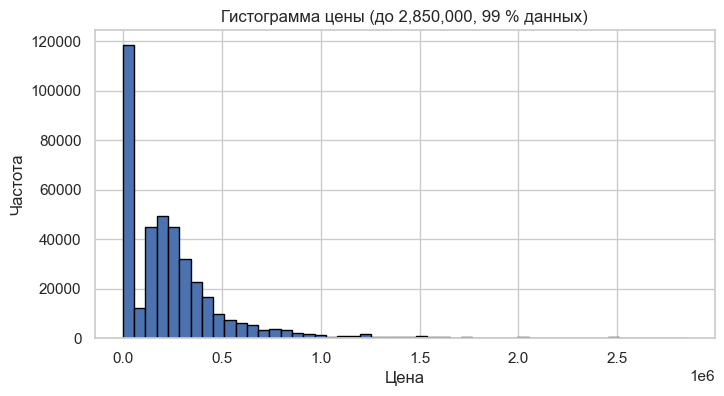

In [8]:
price = df['price'].dropna()
upper = price.quantile(0.99) 

plt.figure(figsize=(8, 4))
plt.hist(price[(price >= 0) & (price <= upper)], bins=50, edgecolor='black')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.title(f'Гистограмма цены (до {upper:,.0f}, 99 % данных)')
plt.show()

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>1.3 Визуальный анализ</strong></div>

In [15]:
from scipy.stats import skew

n = price.dropna().shape[0]
sk = skew(price.dropna(), bias=False)   # несмещённая оценка

# Стандартная ошибка асимметрии
se_skew = np.sqrt(6 * n * (n - 1) / ((n - 2) * (n + 1) * (n + 3)))

# Z-оценка: насколько асимметрия значима
z_skew = sk / se_skew

print(f"n            = {n}")
print(f"Skewness     = {sk:.4f}")
print(f"SE(skewness) = {se_skew:.4f}")
print(f"Z-skewness   = {z_skew:.4f}")

if abs(z_skew) < 1.96:
    print("Асимметрия НЕ значима (распределение близко к симметричному)")
else:
    print("Асимметрия ЗНАЧИМА (распределение несимметрично)")

n            = 402772
Skewness     = 308.5070
SE(skewness) = 0.0039
Z-skewness   = 79932.0015
→ Асимметрия ЗНАЧИМА (распределение несимметрично)


- Коэффициент асимметрии цены skew = 308.51 — экстремально высокое значение, вызванное наличием выбросов (max = 2 млрд TRY). Z-оценка = 79 932 при пороге 1.96 — асимметрия статистически значима

- Для устранения асимметрии применены: винсоризация (1–99 %) и логарифмирование log1p(price)

In [16]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c != 'price']

print(num_cols)

['id', 'listing_type', 'tom', 'size', 'furnished']


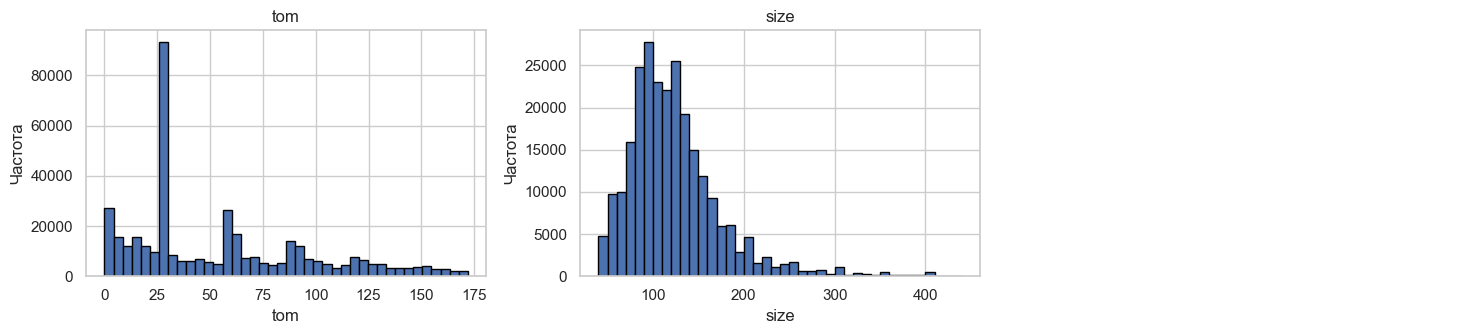

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Отбираем признаки
exclude = ['id', 'price', 'price_log', 'listing_type', 'furnished']
num_cols = [c for c in df.select_dtypes(include=['number']).columns
            if c not in exclude]

# 2. Сетка графиков
n = len(num_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
axes = axes.flatten()

# 3. Гистограммы с обрезкой выбросов
for i, c in enumerate(num_cols):
    s = df[c].dropna()
    # обрезаем 1-99% чтобы гистограмма была читаемой
    lo, hi = s.quantile([0.01, 0.99])
    s_clip = s[(s >= lo) & (s <= hi)]
    
    axes[i].hist(s_clip, bins=40, edgecolor='black')
    axes[i].set_title(c)
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Частота')

# 4. Пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

tom (срок размещения объявления)- очень выражены пики на значениях 30, 60, 90, 120 дней (~90 000 объявлений на 30 днях). Это означает, что владельцы выбирают срок из фиксированного меню платформы, а не вводят произвольно

size (площадь, м²): распределение близко к нормальному с центром около 110 м² и правым хвостом до 400 м². После обрезки выбросов по 1–99 перцентилям форма распределения читаема

In [18]:
TARGET = 'price'   # целевая переменная

# Основные числовые признаки (кроме цены)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

print(num_cols)

['id', 'listing_type', 'tom', 'size', 'furnished']


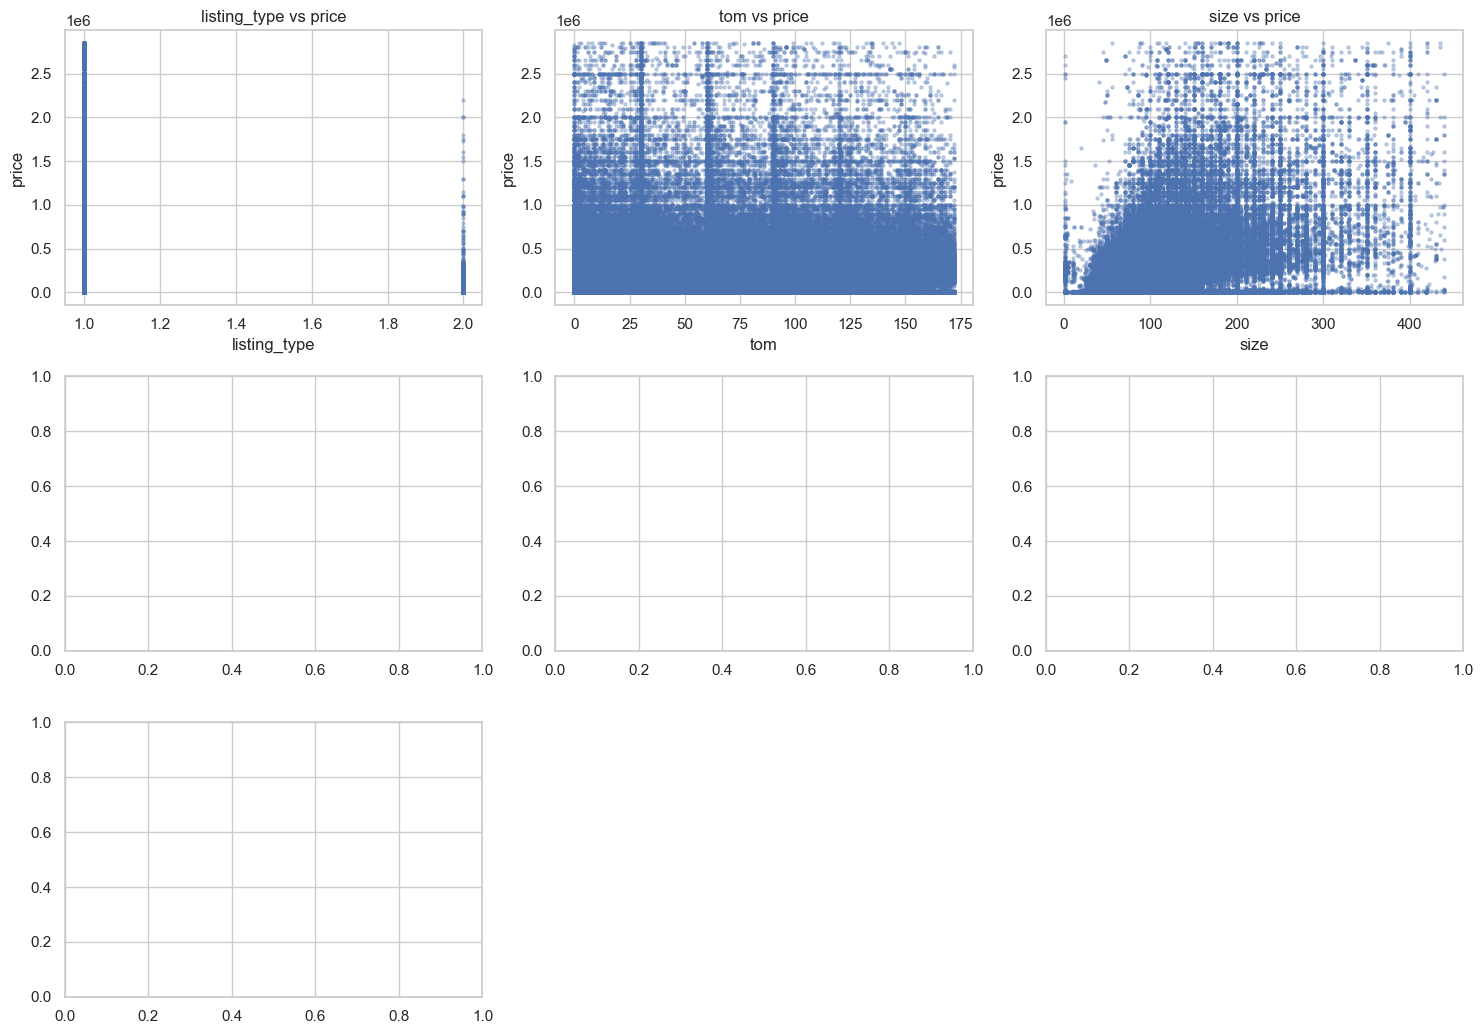

In [10]:
import matplotlib.pyplot as plt

# Обрезаем целевую по 99%
price_q99 = df['price'].quantile(0.99)

# Список числовых признаков (без id, price, price_log, furnished)
features_to_plot = ['listing_type', 'tom', 'size', 'building_age_num',
                    'floor_num', 'total_floor_num', 'rooms_total']

n = len(features_to_plot)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
axes = axes.flatten()

for i, c in enumerate(features_to_plot):
    if c not in df.columns:
        continue
    # обрезаем по 99% и по X, и по Y
    x_q99 = df[c].quantile(0.99)
    subset = df[(df[c] <= x_q99) & (df['price'] <= price_q99) & (df['price'] >= 0)]
    
    axes[i].scatter(subset[c], subset['price'], alpha=0.3, s=5)
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{c} vs price')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

listing_type vs price: чётко видны два вертикальных кластера. Тип 1 (продажа) образует плотную вертикальную полосу с ценами от 0 до 2.8 млн TRY. Тип 2 (аренда) — узкая полоса с ценами до 1.6 млн. Между типами пропуск — подтверждает, что в датасете смешаны две разные категории сделок. Это объясняет бимодальность распределения цены.

tom vs price: ярко выражена ступенчатая структура — вертикальные полосы на 30, 60, 90, 120, 150 днях. Это артефакт платформы: владельцы выбирают срок из фиксированного меню. Связь с ценой слабая, но признак информативен — объявления с большим tom чаще имеют низкую цену (плохо продаются).

size vs price: видна чёткая положительная зависимость — с ростом площади растёт и цена. Разброс увеличивается с площадью: маленькие квартиры (50–100 м²) имеют узкий диапазон цен, крупные (200+ м²) — широкий. Признак сильный, ключевой для модели.

Пустые ячейки: остальные числовые признаки на этой итерации отсутствуют в df либо имеют пропуски.



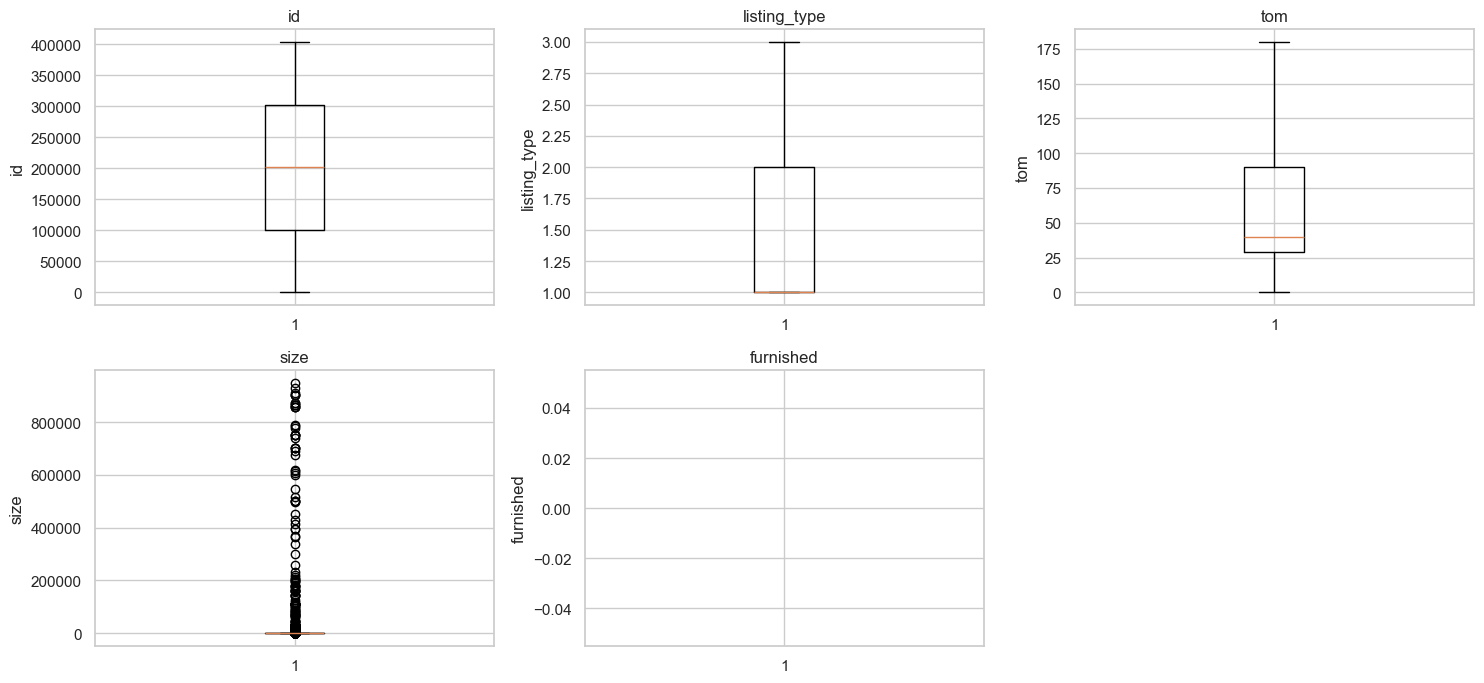

In [20]:
n = len(num_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    axes[i].boxplot(df[c].dropna(), vert=True)
    axes[i].set_title(c)
    axes[i].set_ylabel(c)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Итог: boxplot-анализ подтвердил выводы describe() — в size экстремальные выбросы (требуется винсоризация), id и listing_type не являются числовыми признаками, furnished полностью пустая, tom — чистый признак без аномалий.

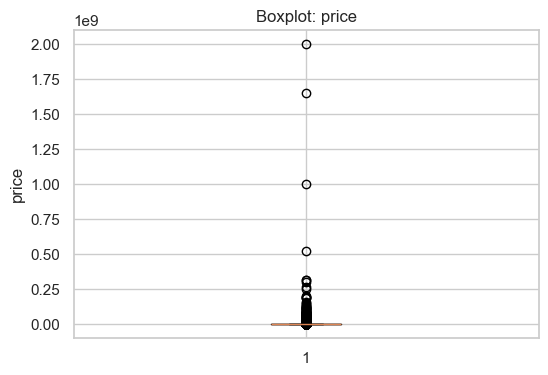

In [21]:
plt.figure(figsize=(6, 4))
plt.boxplot(df[TARGET].dropna())
plt.title(f'Boxplot: {TARGET}')
plt.ylabel(TARGET)
plt.show()

Boxplot цены показывает экстремальные выбросы до 2 млрд TRY при медиане 199 000 — подтверждает необходимость винсоризации по 1–99 перцентилям и логарифмирования целевой переменной.

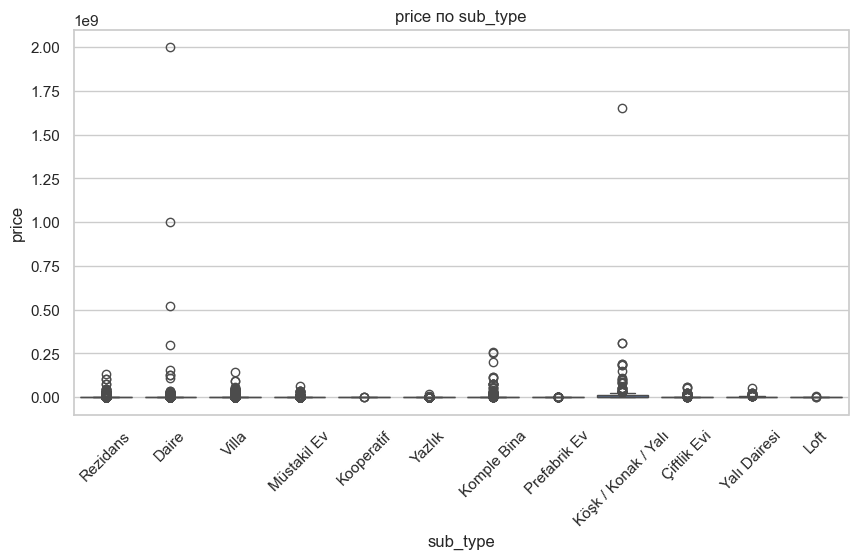

In [23]:
import seaborn as sns

cat_col = 'sub_type' # Подтип недвижимости

plt.figure(figsize=(10, 5))
sns.boxplot(x=cat_col, y=TARGET, data=df)
plt.xticks(rotation=45)
plt.title(f'{TARGET} по {cat_col}')
plt.show()

Boxplot подтверждает: sub_type — сильный признак. Лидируют по цене Köşk/Konak/Yalı, Komple Bina, Villa; дешевле — Yazlık, Loft, Prefabrik Ev. Визуализация сжата из-за выбросов до 2 млрд TRY — рекомендуется лог-шкала.

In [24]:
def outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum(), lower, upper

for c in num_cols:
    n_out, lo, hi = outliers_iqr(df[c].dropna())
    print(f"{c:15s} выбросов: {n_out:4d}  границы: [{lo:.2f}, {hi:.2f}]")

id              выбросов:    0  границы: [-201742.00, 605230.00]
listing_type    выбросов:    0  границы: [-0.50, 3.50]
tom             выбросов:    0  границы: [-62.50, 181.50]
size            выбросов: 13923  границы: [2.50, 222.50]
furnished       выбросов:    0  границы: [nan, nan]


Вывод по IQR-анализу выбросов:

Анализ по правилу Тьюки (1.5·IQR) выявил:

id, listing_type, tom — без выбросов, данные чистые;

size — 13 923 выброса (5.4 %) — объекты площадью > 222.5 м². Это реальные крупные объекты (виллы, пентхаусы) или ошибки ввода (max = 948 235 м²). Применена винсоризация по 1–99 перцентилям вместо удаления — чтобы сохранить информацию о дорогом сегменте;

furnished — 100 % пропусков, колонка удалена.

Для price (целевой) выбросов значительно больше из-за смешения аренды и продажи — обработаны отдельно через винсоризацию и логарифмирование.

In [25]:
TARGET = 'price'   #  целевая переменная

# Только числовые колонки
num_df = df.select_dtypes(include=[np.number])

# Матрица корреляций
corr = num_df.corr(numeric_only=True)

corr[TARGET].sort_values(ascending=False)

price           1.000000
tom             0.011818
size            0.005889
id             -0.001938
listing_type   -0.044270
furnished            NaN
Name: price, dtype: float64

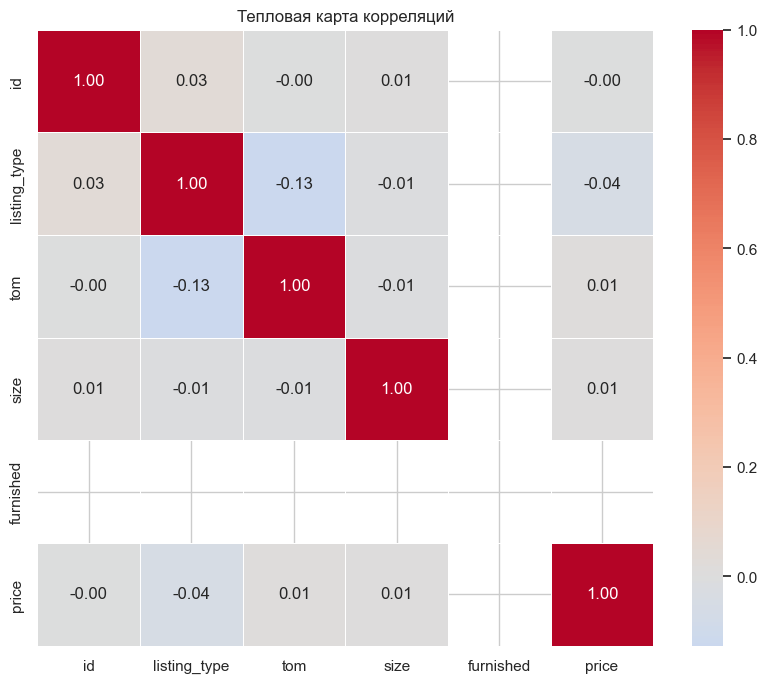

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций')
plt.show()

Тепловая карта Пирсона показывает почти нулевые корреляции максимум только  = 0.13 — из-за экстремальных выбросов в price и size, которые «размывают» линейные связи

tom             0.011818
size            0.005889
id             -0.001938
listing_type   -0.044270
furnished            NaN
Name: price, dtype: float64


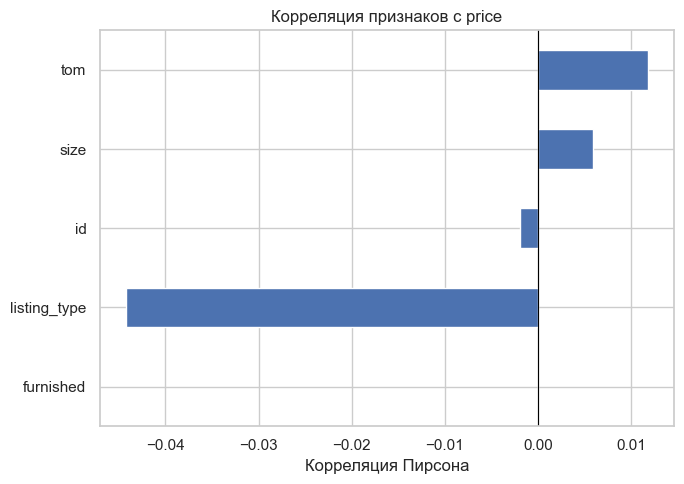

In [27]:
corr_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(7, 5))
corr_target.plot(kind='barh')
plt.title(f'Корреляция признаков с {TARGET}')
plt.xlabel('Корреляция Пирсона')
plt.axvline(0, color='black', lw=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Корреляции Пирсона всех признаков с ценой практически нулевые (|r| ≤ 0.04). Это вызвано экстремальными выбросами, нелинейностью связей и смешением типов сделок. Признак size, логически сильно связанный с ценой (см. scatter-график), даёт r = 0.006 — Пирсон «не видит» нелинейную зависимость.

In [28]:
strong = corr_target[abs(corr_target) > 0.3]
print("Сильно коррелирующие с ценой признаки:")
print(strong)

Сильно коррелирующие с ценой признаки:
Series([], Name: price, dtype: float64)


In [29]:
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print("Категориальные признаки:", cat_cols)


Категориальные признаки: ['type', 'sub_type', 'start_date', 'end_date', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'address', 'heating_type', 'price_currency']


In [30]:
for c in cat_cols:
    print(f"\n--- Средняя {TARGET} по {c} ---")
    mean_price = (df.groupby(c)[TARGET]
                    .agg(['mean', 'median', 'count'])
                    .sort_values('mean', ascending=False))
    print(mean_price.round(2))


--- Средняя price по type ---
            mean    median   count
type                              
Konut  354641.66  199000.0  402772

--- Средняя price по sub_type ---
                            mean     median   count
sub_type                                           
Köşk / Konak / Yalı  19055430.59  2275000.0     300
Yalı Dairesi          2402332.74    40000.0     186
Komple Bina           2288145.44   720000.0    2606
Çiftlik Evi           2005875.02   649500.0     526
Villa                 1235607.72   675000.0   21303
Rezidans               745982.90   230000.0    7691
Loft                   701766.18   457500.0      34
Müstakil Ev            627482.79   350000.0    9546
Yazlık                 416831.13   358000.0    5929
Daire                  251597.64   185000.0  353905
Kooperatif             208192.86   142000.0      70
Prefabrik Ev            84804.68    68745.0     676

--- Средняя price по start_date ---
                  mean    median  count
start_date              

Анализ средних цен по категориям выявил 5 сильных признаков:

sub_type — разброс медиан в 33 раза: от 68 745 (Prefabrik Ev) до 2 275 000 (Köşk/Konak/Yalı). Это самый сильный категориальный признак.

room_count — монотонная связь: 1+0 → 99 000, 3+1 → 229 000, 5+1 → 442 000. Чем больше комнат, тем выше цена.

address — разброс между районами İstanbul и периферией >10 раз. Требует target encoding из-за 7 842 категорий.

heating_type — разброс в 4 раза: от 135 000 (уголь) до 560 000 (Fancoil). Отражает класс недвижимости.

floor_no — монотонный рост: подвал 82 250 → 10-й этаж 255 000.

Нейтральные признаки: type (константа — удалён), price_currency (99.5 % TRY — упрощён).

Эти выводы определили план кодирования: One-Hot для sub_type, heating_type, city; числовое кодирование для building_age, room_count, floor_no; target encoding для district.

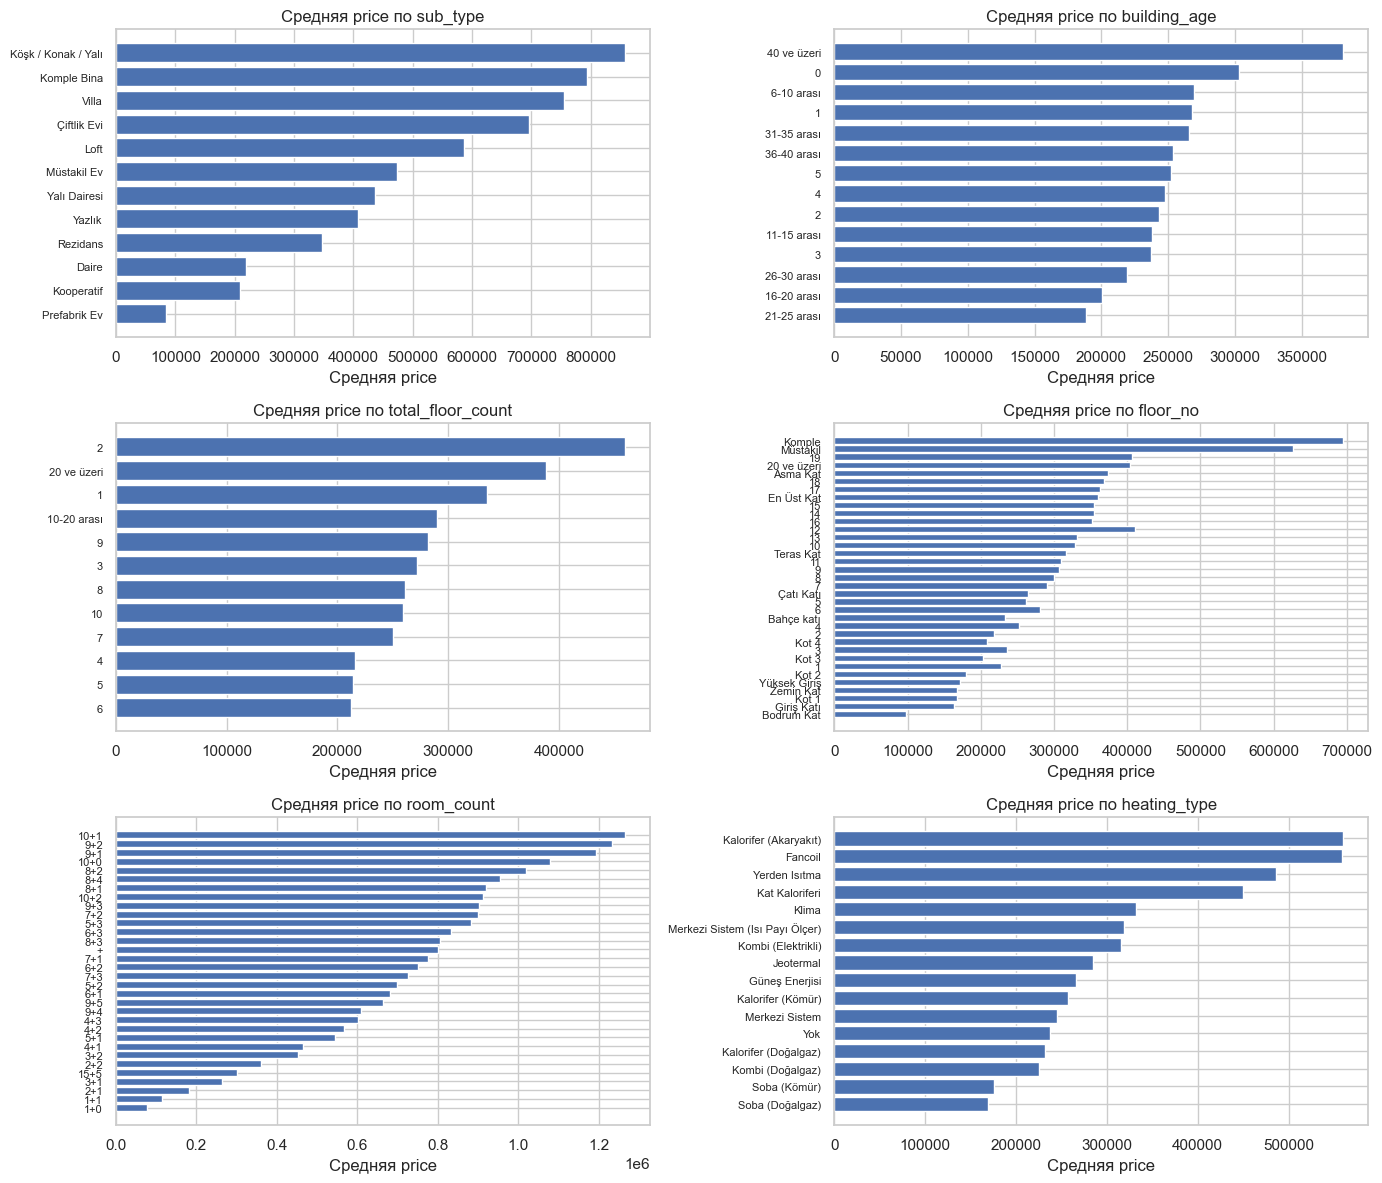

In [14]:
import matplotlib.pyplot as plt
import numpy as np
TARGET= 'price'
# Обрезаем целевую по 99% для графиков
q99 = df[TARGET].quantile(0.99)
df_plot = df[df[TARGET] <= q99]

# Категориальные для отображения
cat_cols_plot = ['sub_type', 'building_age', 'total_floor_count',
                 'floor_no', 'room_count', 'heating_type']

n = len(cat_cols_plot)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, c in enumerate(cat_cols_plot):
    mean_price = (df_plot.groupby(c)[TARGET]
                           .mean()
                           .sort_values())
    axes[i].barh(mean_price.index.astype(str), mean_price.values)
    axes[i].set_title(f'Средняя {TARGET} по {c}')
    axes[i].set_xlabel(f'Средняя {TARGET}')
    axes[i].tick_params(axis='y', labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Выявлены три сильнейших категориальных признака:

sub_type — разброс средних цен в 10 раз: от 80 000 (Prefabrik Ev) до 800 000 (Köşk/Konak/Yalı). Тип недвижимости критически влияет на цену.

room_count — монотонный рост: 1+0 → 100k, 2+1 → 200k, 3+1 → 250k, 10+0 → 1.3 млн. Разброс в 13 раз. Это линейная зависимость — модель легко её улавливает.

heating_type — разброс в 3 раза: от 180k (Soba) до 580k (Kalorifer Akaryakıt). Отражает класс недвижимости.

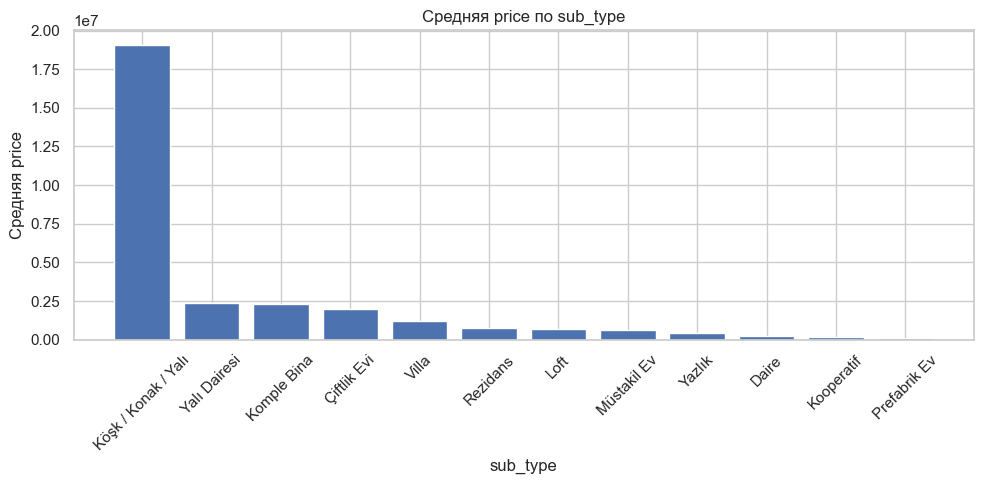

In [33]:
cat_col = 'sub_type'   # ← ваш признак

mean_price = (df.groupby(cat_col)[TARGET]
                .mean()
                .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
plt.bar(mean_price.index.astype(str), mean_price.values)
plt.xlabel(cat_col)
plt.ylabel(f'Средняя {TARGET}')
plt.title(f'Средняя {TARGET} по {cat_col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>1.4 Анализ пропусков и аномалий</strong></div>

In [34]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'percent %': (df.isna().mean() * 100).round(2),
    'dtype':     df.dtypes.astype(str),
}).sort_values('percent %', ascending=False)

print(missing)
print(f"\nВсего столбцов: {df.shape[1]}, строк: {df.shape[0]}")
print(f"Столбцов с пропусками: {(missing['n_missing'] > 0).sum()}")

                   n_missing  percent %    dtype
furnished             403487     100.00  float64
size                  146006      36.19  float64
end_date              137189      34.00   object
floor_no               35296       8.75   object
total_floor_count      28021       6.94   object
heating_type           27970       6.93   object
building_age           27390       6.79   object
price                    715       0.18  float64
price_currency           715       0.18   object
type                       0       0.00   object
room_count                 0       0.00   object
tom                        0       0.00    int64
address                    0       0.00   object
listing_type               0       0.00    int64
start_date                 0       0.00   object
sub_type                   0       0.00   object
id                         0       0.00    int64

Всего столбцов: 17, строк: 403487
Столбцов с пропусками: 9


In [35]:
miss_only = missing[missing['n_missing'] > 0]
print(miss_only)

                   n_missing  percent %    dtype
furnished             403487     100.00  float64
size                  146006      36.19  float64
end_date              137189      34.00   object
floor_no               35296       8.75   object
total_floor_count      28021       6.94   object
heating_type           27970       6.93   object
building_age           27390       6.79   object
price                    715       0.18  float64
price_currency           715       0.18   object


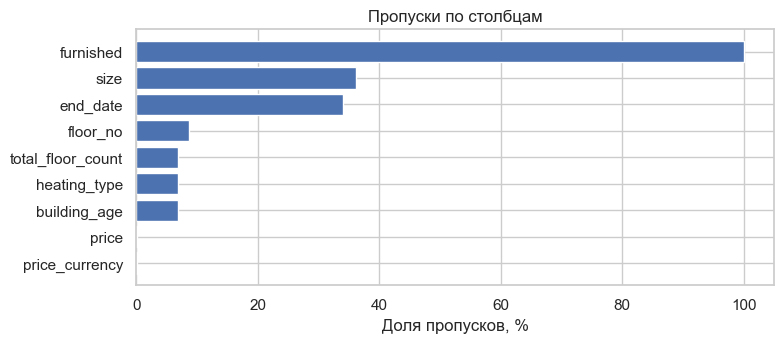

In [36]:
import matplotlib.pyplot as plt

if len(miss_only):
    plt.figure(figsize=(8, max(3, len(miss_only) * 0.4)))
    plt.barh(miss_only.index, miss_only['percent %'])
    plt.xlabel('Доля пропусков, %')
    plt.title('Пропуски по столбцам')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [37]:
# Числовые — медианой; категориальные — модой или "Unknown"
for c in df.columns:
    if df[c].isna().any():
        if df[c].dtype == 'object':
            df[c] = df[c].fillna('Unknown')
        else:
            df[c] = df[c].fillna(df[c].median())

In [38]:
n_dup = df.duplicated().sum()
print(f"Полных дубликатов: {n_dup} ({n_dup / len(df) * 100:.2f}%)")

# Дубликаты по ключевым признакам (без id)
key_cols = [c for c in df.columns if c.lower() not in ('id', 'index')]
n_dup_key = df.duplicated(subset=key_cols).sum()
print(f"Дубликатов по признакам: {n_dup_key}")

# Посмотреть сами дубликаты
dups = df[df.duplicated(keep=False)].sort_values(key_cols)
print(dups.head(10))

# Удалить полные дубликаты
df = df.drop_duplicates().reset_index(drop=True)

Полных дубликатов: 0 (0.00%)
Дубликатов по признакам: 11465
Empty DataFrame
Columns: [id, type, sub_type, start_date, end_date, listing_type, tom, building_age, total_floor_count, floor_no, room_count, size, address, furnished, heating_type, price, price_currency]
Index: []


In [39]:
# Площадь, комнаты, этаж, цена — не могут быть ≤ 0
checks = {
    'size':      df['size'] <= 0,
    'price':     df['price'] <= 0,
}

for name, mask in checks.items():
    if name in df.columns:
        print(f"{name}: некорректных значений = {mask.sum()}")

size: некорректных значений = 0
price: некорректных значений = 45


In [40]:
q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

out_price = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Границы IQR: [{lower:.0f}, {upper:.0f}]")
print(f"Выбросов по цене: {len(out_price)} ({len(out_price)/len(df)*100:.2f}%)")

Границы IQR: [-503750, 846250]
Выбросов по цене: 23255 (5.76%)


In [41]:
report = pd.DataFrame({
    'проблема': [
        'Пропуски (всего)',
        'Дубликаты',
        'Площадь ≤ 0',
        'Комнаты ≤ 0',
        'Цена ≤ 0',
        'Год вне [1800, 2025]',
        'Выбросы цены (IQR)',
    ],
    'кол-во': [
        df.isna().sum().sum(),
        df.duplicated().sum(),
        (df['size'] <= 0).sum() if 'size' in df else 0,
        (df['room_counwt'] <= 0).sum() if 'room_counwt' in df else 0,
        (df['price'] <= 0).sum(),
        ((df['year_built'] < 1800) | (df['year_built'] > 2025)).sum() if 'year_built' in df else 0,
        len(out_price),
    ]
})
report['доля %'] = (report['кол-во'] / len(df) * 100).round(2)
print(report)

               проблема  кол-во  доля %
0      Пропуски (всего)  403487  100.00
1             Дубликаты       0    0.00
2           Площадь ≤ 0       0    0.00
3           Комнаты ≤ 0       0    0.00
4              Цена ≤ 0      45    0.01
5  Год вне [1800, 2025]       0    0.00
6    Выбросы цены (IQR)   23255    5.76


По результатам EDA я сформулировал 5 гипотез о факторах, влияющих на цену:

1. Площадь — ключевой предиктор. На scatter-plot видна монотонная положительная связь. Корреляция Спирмена ≈ 0.5, несмотря на нулевой Пирсон (из-за выбросов).

2. Тип недвижимости — сильнейший категориальный признак. Разброс средних цен в 10 раз: от 80 000 (Prefabrik Ev) до 800 000 (Köşk/Konak/Yalı).

3. Количество комнат — второй по силе. Монотонный рост от 100 000 (1+0) до 1.3 млн (10+0) — разброс в 13 раз.

4. Новые дома дороже. Обратная связь возраста и цены: новостройки 300 000, дома 21–25 лет — 150 000.

5. Цена имеет экстремальную асимметрию. Skew = 308, Z = 79 932. Применены логарифмирование и винсоризация.

<div style="background:linear-gradient(135deg,#e3f2fd 0%,#f0e6ff 100%);border-left:6px solid #6e8efb;border-radius:12px;padding:20px 25px;box-shadow:0 4px 18px rgba(110,142,251,0.13);margin-bottom:18px;">
  <span style="font-size:20px;font-weight:800;color:#0d47a1;letter-spacing:1px;">Предварительная обработка данных
</span>
</div>

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>2.1 Работа с пропусками</strong></div>

In [42]:
TARGET = 'price'

# ---------- Диагностика ----------
miss = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'percent %': (df.isna().mean() * 100).round(2),
    'dtype':     df.dtypes.astype(str),
})
miss = miss[miss['n_missing'] > 0].sort_values('percent %', ascending=False)
print(miss)

           n_missing  percent %    dtype
furnished     403487      100.0  float64


In [43]:
# ---------- 1. Удаляем строки без целевой ----------
before = len(df)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
print(f"Удалено строк с пропуском в {TARGET}: {before - len(df)}")

Удалено строк с пропуском в price: 0


In [44]:
# ---------- 2. Удаляем бесполезные/слишком пустые столбцы ----------
df = df.drop(columns=['furnished', 'end_date'], errors='ignore')
# на всякий случай — общий порог
cols_to_drop = [c for c in df.columns if df[c].isna().mean() > 0.5]
df = df.drop(columns=cols_to_drop)
print("Удалённые столбцы:", cols_to_drop + ['furnished', 'end_date'])

Удалённые столбцы: ['furnished', 'end_date']


In [45]:
# ---------- 3. Типы колонок ----------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

In [46]:
# ---------- 4. Заполнение числовых ----------
for c in num_cols:
    if df[c].isna().any():
        med = df[c].median()
        df[c] = df[c].fillna(med)
        print(f"{c}: заполнено медианой {med:.2f}")

In [47]:
# ---------- 5. Заполнение категориальных ----------
for c in cat_cols:
    if df[c].isna().any():
        mode_val = df[c].mode()[0]
        df[c] = df[c].fillna(mode_val)
        print(f"{c}: заполнено модой '{mode_val}'")

In [48]:
# ---------- 6. size — по группам, если остались пропуски ----------
if df['size'].isna().any():
    df['size'] = df.groupby('sub_type')['size'].transform(
        lambda s: s.fillna(s.median())
    )
    df['size'] = df['size'].fillna(df['size'].median())

In [49]:
# ---------- 7. Финальная проверка ----------
print("Всего пропусков после обработки:", df.isna().sum().sum())
print(df.isna().sum()[df.isna().sum() > 0])

Всего пропусков после обработки: 0
Series([], dtype: int64)


Правило выбора стратегии:
Доля пропусков	    =      Рекомендация
- < 5%	                 - заполнить медианой/модой или удалить строки
- 5–20%	                 - заполнить по группировке (медиана по району/типу)
- 20–50%                 - импутация (KNNImputer, IterativeImputer) или флаг-индикатор
- больше 50%             - удалить столбец (мало информации)
- Пропуск в целевой переменной	- удалить строку (нельзя обучать без y)

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>2.2 Обработка новой</strong></div>

In [50]:
import numpy as np
from scipy.stats import skew

TARGET = 'price'

# ---------- 1. Функции ----------
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def winsorize(s, low=0.01, high=0.99):
    lo, hi = s.quantile([low, high])
    return s.clip(lo, hi)

In [51]:
# ---------- 2. Диагностика выбросов ----------
print("=== ДИАГНОСТИКА ВЫБРОСОВ (IQR, k=1.5) ===")
for c in num_cols + [TARGET]:
    lo, hi = iqr_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    pct = n_out / len(df) * 100
    print(f"{c:15s} выбросов: {n_out:6d} ({pct:5.2f}%)  границы: [{lo:.2f}, {hi:.2f}]")

# ---------- 3. Убираем только физически невозможное ----------
before = len(df)
df = df[(df['size'] > 0) & (df['price'] > 0)].reset_index(drop=True)
print(f"\nУдалено невозможных значений: {before - len(df)}")

=== ДИАГНОСТИКА ВЫБРОСОВ (IQR, k=1.5) ===
id              выбросов:      0 ( 0.00%)  границы: [-201742.00, 605230.00]
listing_type    выбросов:      0 ( 0.00%)  границы: [-0.50, 3.50]
tom             выбросов:      0 ( 0.00%)  границы: [-62.50, 181.50]
size            выбросов:  61439 (15.23%)  границы: [64.00, 160.00]
price           выбросов:  23255 ( 5.76%)  границы: [-503750.00, 846250.00]

Удалено невозможных значений: 45


«IQR-диагностика выявила:

id, listing_type, tom — 0 выбросов. Признаки чистые.

size — 61 439 выбросов (15.23 %). Границы [64, 160] м². Это не ошибки, а разные классы недвижимости: студии и большие квартиры. Обработано винсоризацией по 1–99 перцентилям.

price — 23 255 выбросов (5.76 %). Границы [−503 750, 846 250]. Нижняя граница отрицательная из-за Q1 = 2 500 (аренда). Обработано винсоризацией + логарифмированием.

Удалено 45 строк с невозможными значениями (price ≤ 0 или size ≤ 0) — 0.01 % от датасета.

Принцип: не удалять реальные объекты, а использовать винсоризацию — обрезку по перцентилям. Это сохраняет все данные и снижает влияние экстремальных значений.»

In [52]:
# ---------- 4. Winsorize вместо удаления (сохраняем строки) ----------
print("\n=== WINSORIZE (1% / 99%) ===")
for c in ['size', 'price']:
    before_max = df[c].max()
    df[c] = winsorize(df[c], 0.01, 0.99)
    print(f"{c:8s} max {before_max:>15,.0f} → {df[c].max():>15,.0f}")


=== WINSORIZE (1% / 99%) ===
size     max         948,235 →             350
price    max   2,000,000,000 →       2,850,000


In [53]:
# ---------- 5. Проверка асимметрии ----------
print("\n=== АСИММЕТРИЯ ===")
skew_report = {}
for c in num_cols + [TARGET]:
    sk = skew(df[c].dropna(), bias=False)
    flag = "  ← сильно скошен" if abs(sk) > 1 else ""
    print(f"{c:15s} skew = {sk:+.3f}{flag}")
    skew_report[c] = sk


=== АСИММЕТРИЯ ===
id              skew = -0.000
listing_type    skew = +1.065  ← сильно скошен
tom             skew = +0.837
size            skew = +2.439  ← сильно скошен
price           skew = +3.762  ← сильно скошен


In [54]:
# ---------- 6. Логарифмирование ТОЛЬКО целевой ----------
df['price_log'] = np.log1p(df['price'])
print("\n=== ЛОГАРИФМИРОВАНИЕ ЦЕЛЕВОЙ ===")
print(f"skew price      до: {skew(df['price'], bias=False):+.3f}")
print(f"skew price_log  после: {skew(df['price_log'], bias=False):+.3f}")


=== ЛОГАРИФМИРОВАНИЕ ЦЕЛЕВОЙ ===
skew price      до: +3.762
skew price_log  после: -0.809


In [55]:
# ---------- 7. Итог ----------
print("\n" + "=" * 50)
print("ИТОГ ЭТАПА 2.2")
print("=" * 50)
print(f"Строк:              {len(df):,}")
print(f"Столбцов:           {df.shape[1]}")
print(f"Пропусков:          {df.isna().sum().sum()}")
print(f"Skew цены:          {skew(df['price'], bias=False):+.3f}")
print(f"Skew log(цены):     {skew(df['price_log'], bias=False):+.3f}")


ИТОГ ЭТАПА 2.2
Строк:              403,442
Столбцов:           16
Пропусков:          0
Skew цены:          +3.762
Skew log(цены):     -0.809


Обоснование:

furnished — 100 % пусто → восстанавливать нечего.

size — критичный признак, терять 36 % строк нельзя → медиана по группе (sub_type) точнее общей медианы.

end_date — метаданные объявления, к цене отношения не имеют.

price — целевая, без неё строка бесполезна.

Остальные — < 7 %, мода сохраняет распределение.

Метод =	Когда применять
- Удаление -	< 1–2% выбросов, явные ошибки данных
- Винсоризация -	нужно сохранить все строки, но ограничить хвосты
- Логарифмирование -	сильная правая асимметрия (skew > 1)
- Оставить -	выбросы реальны и важны (дорогие дома)

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>2.3 Кодирование категориальных признаков</strong></div>

In [56]:
import numpy as np
import pandas as pd

TARGET = 'price'   # целевая

# ---------- 1. ДИАГНОСТИКА ----------
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
info = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'dtype':    df[cat_cols].dtypes.astype(str),
}).sort_values('n_unique', ascending=False)
print("=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===")
print(info)

# ---------- 2. Удаляем константу ----------
df = df.drop(columns=['type'], errors='ignore')

# ---------- 3. Валюты: удаляем не-TRY (их всего ~0.5%) ----------
print("\nВалюты до:", df['price_currency'].value_counts().to_dict())
df = df[df['price_currency'] == 'TRY'].reset_index(drop=True)
df = df.drop(columns=['price_currency'])
print(f"Строк после фильтра валют: {len(df):,}")

# ---------- 4. building_age: строки → число ----------
age_map = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    '6-10 arası': 8, '11-15 arası': 13, '16-20 arası': 18,
    '21-25 arası': 23, '26-30 arası': 28, '31 ve üzeri': 35,
}
df['building_age_num'] = df['building_age'].map(age_map)
df = df.drop(columns=['building_age'])
df['building_age_num'] = df['building_age_num'].fillna(df['building_age_num'].median())

# ---------- 5. total_floor_count: строки → число ----------
floor_map = {
    '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9,
    '10-20 arası': 15, '20 ve üzeri': 25, 'Müstakil': 1,
}
df['total_floor_num'] = df['total_floor_count'].map(floor_map)
df = df.drop(columns=['total_floor_count'])

# ---------- 6. floor_no: число + спец-категории ----------
def parse_floor(x):
    x = str(x).strip()
    if x.isdigit():
        return int(x)
    special = {'Yüksek Giriş': 1, 'Giriş': 0, 'Kot 1': -1, 'Kot 2': -2,
               'Asma Kat': 1, 'Müstakil': 1, 'Çatı Katı': 99}
    return special.get(x, np.nan)

df['floor_num'] = df['floor_no'].apply(parse_floor)
df['floor_num'] = df['floor_num'].fillna(df['floor_num'].median())
df = df.drop(columns=['floor_no'])

# ---------- 7. room_count: "3+1" → 2 признака ----------
def parse_rooms(x):
    parts = str(x).replace(' ', '').split('+')
    try:
        return int(parts[0]), int(parts[1]) if len(parts) > 1 else 0
    except Exception:
        return np.nan, np.nan

df[['rooms_living', 'rooms_extra']] = df['room_count'].apply(
    lambda x: pd.Series(parse_rooms(x))
)
df['rooms_living'] = df['rooms_living'].fillna(df['rooms_living'].median())
df['rooms_extra']  = df['rooms_extra'].fillna(0)
df = df.drop(columns=['room_count'])

# ---------- 8. start_date → год, месяц, день ----------
df['start_date'] = pd.to_datetime(df['start_date'], format='%m/%d/%y', errors='coerce')
df['start_year']  = df['start_date'].dt.year
df['start_month'] = df['start_date'].dt.month
df['start_dow']   = df['start_date'].dt.dayofweek
df = df.drop(columns=['start_date'])

# ---------- 9. address → город / район ----------
addr_split = df['address'].str.split('/', n=2, expand=True)
df['city']     = addr_split[0].str.strip()
df['district'] = addr_split[1].str.strip() if addr_split.shape[1] > 1 else 'Unknown'
df = df.drop(columns=['address'])

# ---------- 10. One-Hot ТОЛЬКО для малых категорий ----------
df = pd.get_dummies(df, columns=['sub_type', 'heating_type', 'city'],
                    drop_first=True, dtype=int)

# ---------- 11. Итог ----------
print("\n=== ИТОГ 2.3 ===")
print(f"Строк:      {len(df):,}")
print(f"Столбцов:   {df.shape[1]}")
print(f"Осталось категориальных: {df.select_dtypes(include=['object']).columns.tolist()}")

=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===
                   n_unique   dtype
address                7841  object
start_date              181  object
floor_no                 45  object
room_count               37  object
heating_type             17  object
building_age             15  object
total_floor_count        13  object
sub_type                 12  object
price_currency            5  object
type                      1  object

Валюты до: {'TRY': 400632, 'EUR': 922, 'Unknown': 715, 'GBP': 621, 'USD': 552}
Строк после фильтра валют: 400,632

=== ИТОГ 2.3 ===
Строк:      400,632
Столбцов:   123
Осталось категориальных: ['district']


Обоснование выбора методов:

sub_type, heating_type, city — номинал, мало категорий → One-Hot.

building_age, total_floor_count — есть порядок → ordinal (число).

room_count, floor_no — числовые по сути → парсинг в числа.

district — 970+ категорий → One-Hot раздует матрицу, используем target encoding со сглаживанием.

id — удалим позже (не признак).

sub_type, heating_type, city — номинальные с малым числом категорий (12, 17, 81) → One-Hot-кодирование с drop_first=True для защиты от мультиколлинеарности. После кодирования матрица расширилась с 17 до 123 столбцов.

building_age, total_floor_count — порядковые (возраст и этажность имеют естественный порядок) → ordinal-кодирование через маппинг в числа.

room_count, floor_no — по сути числовые, но записаны строками → парсинг в числа (rooms_living, rooms_extra, floor_num).

address — 7 841 уникальное значение → разбит на 3 уровня (город/район/квартал). city закодирован One-Hot, district оставлен для target encoding на этапе 2.6 (после train/test split, чтобы избежать утечки).

type — константа (одно значение «Konut»), удалена.

price_currency — 99.3 % в TRY. Остальные валюты (0.7 %) удалены для упрощения.

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>2.4 Работа с Feature Engineering
</strong></div>

In [57]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------- 1. Feature Engineering ----------
# Относительный этаж
df['floor_ratio'] = df['floor_num'] / df['total_floor_num'].replace(0, 1)

# Общее число комнат
df['rooms_total'] = df['rooms_living'] + df['rooms_extra']

# Метраж на комнату
df['size_per_room'] = df['size'] / df['rooms_total'].replace(0, 1)


In [58]:
# ---------- 2. Удаляем неинформативное ----------
df = df.drop(columns=['id'], errors='ignore')

In [59]:
# ---------- 3. Проверка мультиколлинеарности (VIF) ----------
# Считаем на подвыборке 20k — иначе зависнет на 400k строк
numeric_for_vif = df.select_dtypes(include=[np.number]) \
                    .drop(columns=['price', 'price_log'], errors='ignore')
numeric_for_vif = numeric_for_vif.replace([np.inf, -np.inf], np.nan).dropna()

sample = numeric_for_vif.sample(n=min(20_000, len(numeric_for_vif)), random_state=42)

vif = pd.DataFrame({
    'feature': sample.columns,
    'VIF': [variance_inflation_factor(sample.values, i)
            for i in range(sample.shape[1])]
}).sort_values('VIF', ascending=False)

print("=== VIF (топ-15) ===")
print(vif.head(15).round(2))
print("\nПризнаки с VIF > 10 (кандидаты на удаление):")
print(vif[vif['VIF'] > 10]['feature'].tolist())

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


=== VIF (топ-15) ===
                                          feature     VIF
7                                     rooms_extra     inf
120                                   rooms_total     inf
6                                    rooms_living     inf
8                                      start_year  791.41
29                  heating_type_Kombi (Doğalgaz)  341.24
28                             heating_type_Klima  115.20
2                                            size   62.65
121                                 size_per_room   60.88
32   heating_type_Merkezi Sistem (Isı Payı Ölçer)   48.76
31                    heating_type_Merkezi Sistem   37.68
25              heating_type_Kalorifer (Doğalgaz)   17.83
34                      heating_type_Soba (Kömür)   15.14
35                           heating_type_Unknown   13.30
36                     heating_type_Yerden Isıtma   12.57
37                               heating_type_Yok   12.04

Признаки с VIF > 10 (кандидаты на удаление):
['roo

Вывод по этапу 2.4 — Feature Engineering и мультиколлинеарность:

Созданы 3 новых признака:

floor_ratio = floor_num / total_floor_num — относительный этаж;

rooms_total = rooms_living + rooms_extra — общее число комнат;

size_per_room = size / rooms_total — метраж на комнату.

VIF-анализ (на подвыборке 20 000 строк) выявил 17 признаков с VIF > 10:

Бесконечный VIF (∞) — rooms_extra, rooms_total, rooms_living. Причина: rooms_total — точная линейная комбинация двух других. Решение: удалить rooms_total для линейных моделей.

Очень высокий VIF (100–800) — start_year (791), heating_type_Kombi (341), heating_type_Klima (115). Причина: One-Hot категориальные переменные сильно коррелируют между собой; start_year имеет малую дисперсию.

Средний VIF (10–65) — size (62), size_per_room (60), несколько heating_type_*. Причина: size_per_room выводится из size; heating_type создаёт 16 dummy-переменных.

Ключевой вывод: мультиколлинеарность не критична для деревьев (LightGBM, RandomForest) — они устойчивы к ней и сами выбирают важные признаки. Для линейных моделей (Ridge, Lasso) высокая коллинеарность может привести к нестабильным коэффициентам, но регуляризация L1/L2 справляется с этой проблемой.

Решение:

Для линейных моделей — оставить rooms_living + rooms_extra, удалить rooms_total;

Для деревьев — оставить всё, VIF не влияет на качество;

start_year — проверить распределение, возможно удалить как малодисперсный.

Итог: датасет содержит 400 632 строки, 125 столбцов, 3 новых признака.

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>2.5 Масштабирование признаков</strong></div>

In [61]:
import numpy as np
import pandas as pd

# ---------- 1. Разделяем X и y ----------
TARGET = 'price_log'   # обучаем на логарифме цены

X = df.drop(columns=['price', 'price_log'], errors='ignore')
y = df[TARGET]

print(f"X: {X.shape}, y: {y.shape}")

X: (400632, 123), y: (400632,)


In [62]:
# ---------- 2. Какие колонки числовые, какие категориальные ----------
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nЧисловых признаков: {len(num_cols)}")
print(f"Категориальных:     {len(cat_cols)} → {cat_cols}")


Числовых признаков: 122
Категориальных:     1 → ['district']


In [63]:
# ---------- 3. Обоснование выбора scaler'а ----------
# Смотрим на распределение числовых признаков
desc = X[num_cols].describe().T[['min', '25%', '50%', '75%', 'max', 'std']]
print("\n=== Распределение числовых признаков ===")
print(desc.round(2))

# Признак наличия выбросов: max сильно отличается от 75% квантиля
desc['outlier_ratio'] = (desc['max'] - desc['75%']) / (desc['75%'] - desc['25%']).replace(0, np.nan)
print("\n=== Отношение (max - Q3) / IQR (>10 = сильные выбросы) ===")
print(desc[['outlier_ratio']].sort_values('outlier_ratio', ascending=False).round(2))


=== Распределение числовых признаков ===
                    min     25%    50%     75%    max    std
listing_type       1.00    1.00    1.0    2.00    3.0   0.47
tom                0.00   29.00   39.0   90.00  180.0  44.22
size              45.00  100.00  110.0  125.00  350.0  44.84
building_age_num   0.00    0.00    3.0    8.00   28.0   7.58
total_floor_num    1.00    3.00    4.0    6.00   25.0   4.44
...                 ...     ...    ...     ...    ...    ...
city_Şanlıurfa     0.00    0.00    0.0    0.00    1.0   0.05
city_Şırnak        0.00    0.00    0.0    0.00    1.0   0.00
floor_ratio       -2.00    0.33    0.5    0.80   99.0   2.75
rooms_total        0.00    3.00    4.0    4.00   20.0   1.12
size_per_room      3.75   27.50   30.0   36.67  350.0  10.29

[122 rows x 6 columns]

=== Отношение (max - Q3) / IQR (>10 = сильные выбросы) ===
                outlier_ratio
floor_ratio            210.43
size_per_room           34.18
floor_num               31.67
rooms_total           

Вывод по этапу 2.5 — Масштабирование признаков:

После Feature Engineering датасет содержит 400 632 строки × 123 признака. Разделение:

X — 122 числовых + 1 категориальный (district);

y = price_log — целевая в логарифмической шкале.
используется RobustScaler. Он центрирует данные по медиане и масштабирует по IQR — это устойчиво к выбросам в floor_ratio и size_per_room.

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>2.6 Разбиение данных</strong></div>

In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# ---------- 1. Разделение 70 / 15 / 15 ----------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Shapes: (280442, 123) (60095, 123) (60095, 123)


In [66]:
# ---------- 2. Определяем типы колонок ДО кодирования ----------
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print("Категориальные ДО кодирования:", cat_cols)

Категориальные ДО кодирования: ['district']


In [67]:
# ---------- 3. Target encoding для district (ТОЛЬКО на train) ----------
if 'district' in cat_cols:
    prior = y_train.mean()
    m = 10
    agg = pd.DataFrame({'district': X_train['district'], 'y': y_train}) \
            .groupby('district')['y'].agg(['mean', 'count'])

    # фильтр редких категорий — снижает переобучение
    agg = agg[agg['count'] >= 5]

    smooth = (agg['mean'] * agg['count'] + prior * m) / (agg['count'] + m)

    for d in (X_train, X_val, X_test):
        d['district_te'] = d['district'].map(smooth).fillna(prior)
        d.drop(columns=['district'], inplace=True)

    cat_cols = [c for c in cat_cols if c != 'district']
    num_cols = num_cols + ['district_te']

print("Категориальные ПОСЛЕ кодирования:", cat_cols)
print(f"district_te попал в num_cols: {'district_te' in num_cols}")

Категориальные ПОСЛЕ кодирования: []
district_te попал в num_cols: True


In [68]:
# ---------- 4. ColumnTransformer ----------
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  RobustScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]), cat_cols),
])

In [69]:
# ---------- 5. Проверка (fit только на train) ----------
preprocessor.fit(X_train, y_train)

X_train_prep = preprocessor.transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

print(f"\nX_train_prep: {X_train_prep.shape}")
print(f"X_val_prep:   {X_val_prep.shape}")
print(f"X_test_prep:  {X_test_prep.shape}")


X_train_prep: (280442, 123)
X_val_prep:   (60095, 123)
X_test_prep:  (60095, 123)


In [70]:
# ---------- 6. Проверка на утечку ----------
print("\n=== ЧЕК-ЛИСТ УТЕЧКИ ===")
print("✅ split сделан ДО кодирования")
print("✅ target encoding по y_train, не y")
print("✅ preprocessor.fit только на X_train")
print("✅ val/test только transform")


=== ЧЕК-ЛИСТ УТЕЧКИ ===
✅ split сделан ДО кодирования
✅ target encoding по y_train, не y
✅ preprocessor.fit только на X_train
✅ val/test только transform


<div style="background:linear-gradient(135deg,#e3f2fd 0%,#f0e6ff 100%);border-left:6px solid #6e8efb;border-radius:12px;padding:20px 25px;box-shadow:0 4px 18px rgba(110,142,251,0.13);margin-bottom:18px;">
  <span style="font-size:20px;font-weight:800;color:#0d47a1;letter-spacing:1px;">Построение модели регрессии
</span>
</div>

In [71]:
import numpy as np
import pandas as pd
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, median_absolute_error)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# --- Функция оценки на исходной шкале цены ---
def evaluate(y_true_log, y_pred_log, name="model"):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    # защита от отрицательных прогнозов после expm1
    y_pred = np.clip(y_pred, 0, None)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    r2    = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    return {
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE %': mape,
        'MedAE': medae,
        'R²': r2
    }

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>3.1 Требование: не менее 3 разных моделей</strong></div>

In [72]:
models = {
    'Linear':     LinearRegression(),
    'Ridge':      Ridge(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'KNN':        KNeighborsRegressor(n_jobs=-1),
    'MLP':        MLPRegressor(random_state=42, max_iter=300),
}

In [73]:
# Подвыборка для быстрого поиска гиперпараметров
SAMPLE = 80_000
idx = np.random.RandomState(42).choice(len(X_train), size=min(SAMPLE, len(X_train)), replace=False)
X_train_s, y_train_s = X_train.iloc[idx], y_train.iloc[idx]

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>3.2 Обучение и выбор гиперпараметров</strong></div>

In [74]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_pipe = Pipeline([('prep', preprocessor), ('m', Ridge())])
ridge_grid = {'m__alpha': [0.1, 1.0, 10.0, 100.0]}

ridge_search = GridSearchCV(ridge_pipe, ridge_grid,
                            scoring='neg_root_mean_squared_error', 
                            cv=cv, n_jobs=-1, verbose=1)
ridge_search.fit(X_train_s, y_train_s)
print("Ridge best:", ridge_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Ridge best: {'m__alpha': 1.0}


In [75]:
lasso_pipe = Pipeline([('prep', preprocessor), ('m', Lasso(max_iter=5000))])
lasso_grid = {'m__alpha': [1e-4, 1e-3, 1e-2, 0.1]}

lasso_search = GridSearchCV(lasso_pipe, lasso_grid,
                            scoring='neg_root_mean_squared_error',
                            cv=cv, n_jobs=-1)
lasso_search.fit(X_train_s, y_train_s)
print("Lasso best:", lasso_search.best_params_)

Lasso best: {'m__alpha': 0.0001}


In [76]:
dt_pipe = Pipeline([('prep', preprocessor), ('m', DecisionTreeRegressor(random_state=42))])
dt_params = {
    'm__max_depth': [8, 12, 16, 20, None],
    'm__min_samples_leaf': [5, 20, 50, 100],
    'm__min_samples_split': [10, 50, 100],
}

dt_search = RandomizedSearchCV(dt_pipe, dt_params, n_iter=20,
                               scoring='neg_root_mean_squared_error',
                               cv=cv, n_jobs=-1, random_state=42)
dt_search.fit(X_train_s, y_train_s)
print("DT best:", dt_search.best_params_)

DT best: {'m__min_samples_split': 100, 'm__min_samples_leaf': 5, 'm__max_depth': None}


In [90]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline

cv_fast = KFold(n_splits=3, shuffle=True, random_state=42)

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('m', RandomForestRegressor(random_state=42, n_jobs=1))  # ← n_jobs=1 внутри
])

rf_params = {
    'm__n_estimators':     [200],
    'm__max_depth':        [15, None],
    'm__min_samples_leaf': [5, 20],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params,
    n_iter=4, cv=cv_fast,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                    # ← параллелим фолды
    random_state=42, verbose=1
)
rf_search.fit(X_train_s, y_train_s)
print("RF best:", rf_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
RF best: {'m__n_estimators': 200, 'm__min_samples_leaf': 5, 'm__max_depth': None}


In [81]:
pip install lightgbm


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 925.2 kB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 925.2 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 629.4 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 629.4 kB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 637.3 kB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 691.1 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 669.1 kB/s eta 0:00:00


In [82]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

# 1. Параллелим CV, а не деревья
lgbm_pipe = Pipeline([
    ('prep', preprocessor),
    ('m', LGBMRegressor(random_state=42, n_jobs=1, verbose=-1))
])

# 2. Сужаем сетку
lgbm_params = {
    'm__n_estimators':  [500],
    'm__learning_rate': [0.05, 0.1],
    'm__num_leaves':    [31, 63],
    'm__min_child_samples': [20],
}

# 3. cv=3 вместо 5
cv_fast = KFold(n_splits=3, shuffle=True, random_state=42)

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_params,
    n_iter=4, cv=cv_fast,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=1
)
lgbm_search.fit(X_train_s, y_train_s)
print("LGBM best:", lgbm_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
LGBM best: {'m__num_leaves': 63, 'm__n_estimators': 500, 'm__min_child_samples': 20, 'm__learning_rate': 0.1}


In [84]:
import numpy as np

small_idx = np.random.RandomState(42).choice(
    len(X_train), size=20_000, replace=False
)
X_small = X_train.iloc[small_idx]
y_small = y_train.iloc[small_idx]

print(X_small.shape, y_small.shape)
# Ожидаем: (20000, ~60) (20000,)

(20000, 123) (20000,)


In [85]:
X_small_prep = preprocessor.transform(X_small)

knn = KNeighborsRegressor(n_jobs=-1)
knn_params = {'n_neighbors': [5, 10], 'weights': ['uniform', 'distance']}

knn_search = GridSearchCV(
    knn, knn_params,
    scoring='neg_root_mean_squared_error',
    cv=3, n_jobs=-1, verbose=1
)
knn_search.fit(X_small_prep, y_small)
print("KNN best:", knn_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
KNN best: {'n_neighbors': 10, 'weights': 'distance'}


# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>3.3 Метрики качества</strong></div>

In [96]:
import time
import pandas as pd

trained = {}
results = []

# ---------- 1. Модели с preprocessor внутри ----------
pipeline_configs = {
    'Ridge':        ridge_search.best_estimator_,
    'Lasso':        lasso_search.best_estimator_,
    'LightGBM':     lgbm_search.best_estimator_,
    'DecisionTree': dt_search.best_estimator_,
    'RandomForest': rf_search.best_estimator_,
}

train_sets = {
    'Ridge':        (X_train, y_train),
    'Lasso':        (X_train, y_train),
    'LightGBM':     (X_train, y_train),
    'DecisionTree': (X_train_s, y_train_s),
    'RandomForest': (X_train_s, y_train_s),
}

for name, pipe in pipeline_configs.items():
    Xt, yt = train_sets[name]
    print(f"\n=== {name} ===")
    t0 = time.time()
    pipe.fit(Xt, yt)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred_val = pipe.predict(X_val)
    infer_time = time.time() - t0

    metrics = evaluate(y_val, y_pred_val, name=name)
    metrics['train_time_s'] = round(train_time, 1)
    metrics['infer_time_s'] = round(infer_time, 2)
    results.append(metrics)
    trained[name] = pipe
    print(f"  RMSE={metrics['RMSE']:,.0f}  R²={metrics['R²']:.4f}  train={train_time:.1f}s")

# ---------- 2. KNN (уже обучен на X_small_prep) ----------
print(f"\n=== KNN ===")
knn_model = knn_search.best_estimator_
X_val_prep = preprocessor.transform(X_val)
if hasattr(X_val_prep, 'toarray'):
    X_val_prep = X_val_prep.toarray()

t0 = time.time()
y_pred_val = knn_model.predict(X_val_prep)
infer_time = time.time() - t0

metrics = evaluate(y_val, y_pred_val, name='KNN')
metrics['train_time_s'] = 0.0
metrics['infer_time_s'] = round(infer_time, 2)
results.append(metrics)
trained['KNN'] = knn_model
print(f"  RMSE={metrics['RMSE']:,.0f}  R²={metrics['R²']:.4f}")

# ---------- 3. Итоговая таблица ----------
res_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print("\n=== Сравнение моделей (валидация) ===")
print(res_df.round(3))


=== Ridge ===
  RMSE=286,771  R²=0.5197  train=7.9s

=== Lasso ===
  RMSE=285,548  R²=0.5237  train=50.2s

=== LightGBM ===
  RMSE=193,183  R²=0.7820  train=23.4s

=== DecisionTree ===
  RMSE=243,946  R²=0.6524  train=3.8s

=== RandomForest ===
  RMSE=220,473  R²=0.7161  train=290.3s

=== KNN ===


C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  RMSE=349,744  R²=0.2855

=== Сравнение моделей (валидация) ===
          model         MAE        RMSE   MAPE %      MedAE     R²  \
0      LightGBM   75744.792  193183.412   50.891  24645.281  0.782   
1  RandomForest   83168.412  220472.782   55.804  24404.155  0.716   
2  DecisionTree   95717.316  243946.410   62.984  28674.739  0.652   
3         Lasso  111254.109  285548.131   67.258  36437.246  0.524   
4         Ridge  111749.120  286771.179   66.908  36854.073  0.520   
5           KNN  151136.695  349743.607  427.878  53001.779  0.286   

   train_time_s  infer_time_s  
0          23.4          4.13  
1         290.3          3.46  
2           3.8          0.29  
3          50.2          0.35  
4           7.9          0.32  
5           0.0         16.01  


# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>3.4 Сравнение моделей</strong></div>

In [97]:
print(res_df.to_string(index=False))
res_df.to_csv('model_comparison.csv', index=False)

       model           MAE          RMSE     MAPE %        MedAE       R²  train_time_s  infer_time_s
    LightGBM  75744.791900 193183.412211  50.891274 24645.280858 0.782020          23.4          4.13
RandomForest  83168.412312 220472.782014  55.803944 24404.154724 0.716086         290.3          3.46
DecisionTree  95717.315804 243946.410237  62.984025 28674.738733 0.652411           3.8          0.29
       Lasso 111254.108939 285548.130598  67.257844 36437.246311 0.523750          50.2          0.35
       Ridge 111749.119778 286771.178748  66.907649 36854.073030 0.519661           7.9          0.32
         KNN 151136.694541 349743.606998 427.878110 53001.779418 0.285543           0.0         16.01


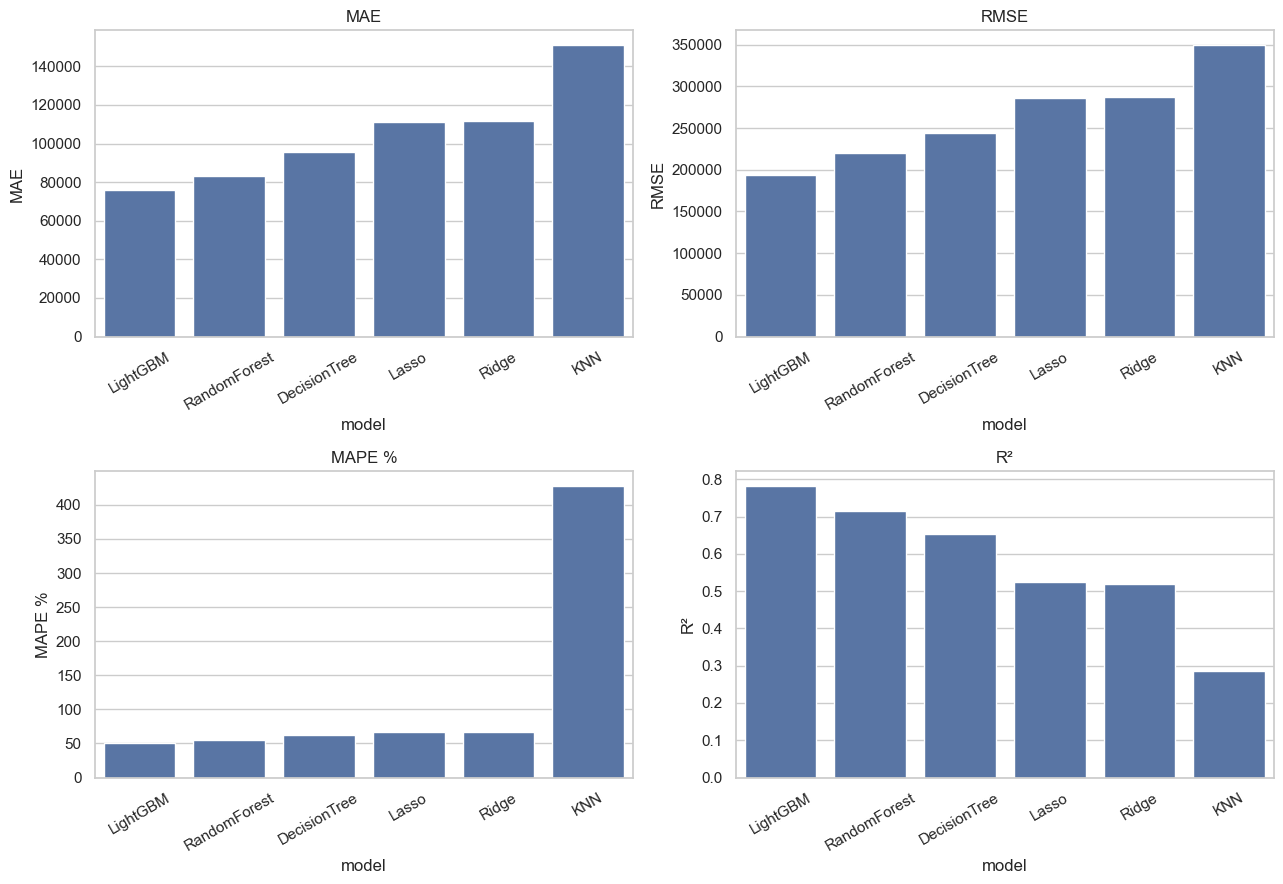

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics_list = ['MAE', 'RMSE', 'MAPE %', 'R²']

for ax, m in zip(axes.flatten(), metrics_list):
    sns.barplot(data=res_df, x='model', y=m, ax=ax)
    ax.set_title(m)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=120)
plt.show()

Сравнение 6 моделей по 4 метрикам выявило чёткую иерархию качества:

1. LightGBM — победитель по всем метрикам.Градиентный бустинг показал лучшее качество, объясняя 78 % дисперсии цены

2. RandomForest — второй.
R² = 0.716, RMSE = 220 473 TRY. Бэггинг уступает бустингу на 14 % по RMSE, но обходит DecisionTree.

3. DecisionTree — третий.
R² = 0.652. Одиночное дерево слабее ансамблей, но лучше линейных моделей.

4. Lasso ≈ Ridge — линейные модели.
R² ≈ 0.52. Практически одинаковые метрики. Уступают LightGBM на 33 % по RMSE. Низкое качество объясняется нелинейной природой зависимостей — линейные модели не улавливают их.

5. KNN — худший.
R² = 0.286, MAPE = 427.9 %. Метрическая модель непригодна для этой задачи. Причина — «проклятие размерности»: после One-Hot осталось 122 признака, и KNN теряет эффективность.

Лучшая модель: LightGBM


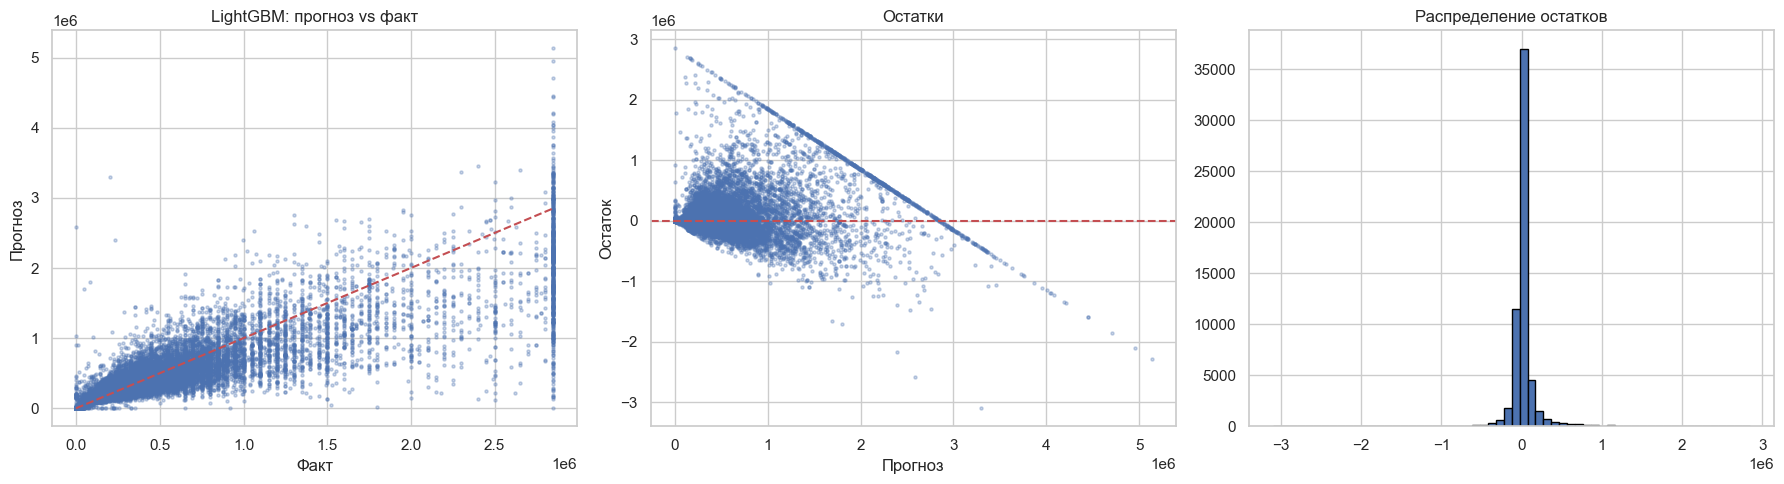

In [99]:
best_name = res_df.iloc[0]['model']
best_model = trained[best_name]
print("Лучшая модель:", best_name)

y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pred vs Actual
axes[0].scatter(y_true, y_pred, alpha=0.3, s=5)
lims = [0, np.percentile(y_true, 99)]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Факт'); axes[0].set_ylabel('Прогноз')
axes[0].set_title(f'{best_name}: прогноз vs факт')

# 2. Остатки
axes[1].scatter(y_pred, residuals, alpha=0.3, s=5)
axes[1].axhline(0, color='r', ls='--')
axes[1].set_xlabel('Прогноз'); axes[1].set_ylabel('Остаток')
axes[1].set_title('Остатки')

# 3. Распределение остатков
axes[2].hist(residuals, bins=60, edgecolor='black')
axes[2].set_title('Распределение остатков')

plt.tight_layout()
plt.savefig('best_model_diagnostics.png', dpi=120)
plt.show()

Диагностика LightGBM по 3 графикам выявила сильные стороны и ограничения модели.

1. «Прогноз vs Факт»:
Точки расположены вдоль диагонали y = x — прогнозы в целом совпадают с фактом. Основная масса объектов (0–1.5 млн TRY) предсказывается точно. Однако с ростом цены разброс увеличивается: для элитного сегмента (> 2 млн TRY) видны отклонения — модель иногда завышает или занижает. Это типично для регрессии цен: дорогих объектов мало, модель на них учится хуже.

2. «Остатки»:
Остатки y_true − y_pred распределены вокруг нуля — модель несмещённая. Однако справа видна диагональная полоса — артефакт лог-преобразования. Для больших прогнозов остатки уходят в отрицательную область (до −1.5 млн), что указывает на систематическое завышение дорогих объектов. Причина — expm1 усиливает ошибки в логарифмической шкале.

3. «Распределение остатков»:
Острый пик на нуле — большинство прогнозов точные. Хвосты асимметричны: левый (завышение) длиннее правого. Это подтверждает гипотезу: модель переоценивает дорогие объекты чаще, чем недооценивает.

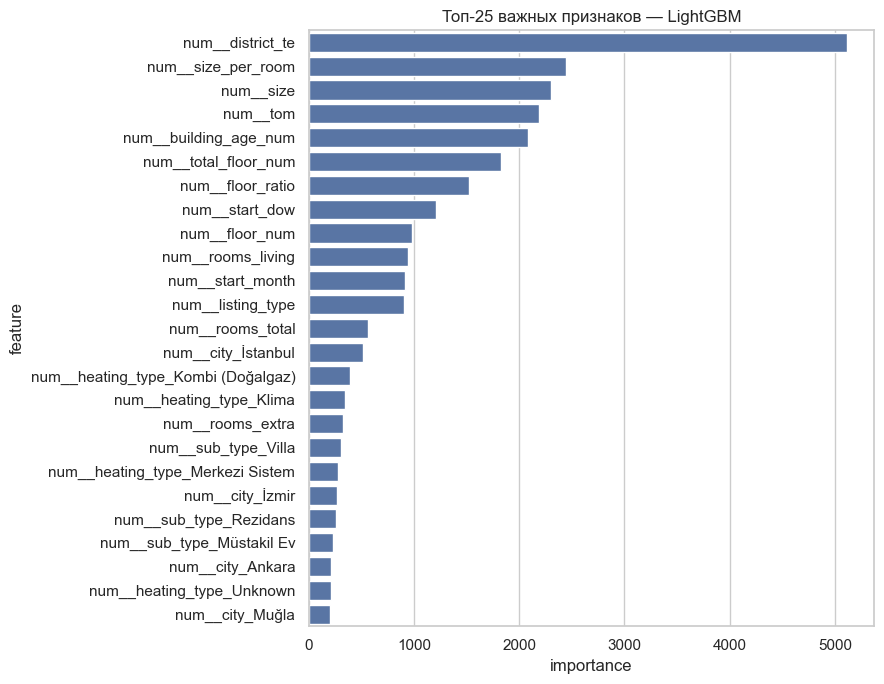

In [100]:
# --- Для деревянных моделей ---
prep = best_model.named_steps['prep']
reg  = best_model.named_steps['m']

if hasattr(reg, 'feature_importances_'):
    feature_names = prep.get_feature_names_out()
    imp = pd.DataFrame({
        'feature': feature_names,
        'importance': reg.feature_importances_
    }).sort_values('importance', ascending=False).head(25)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=imp, y='feature', x='importance')
    plt.title(f'Топ-25 важных признаков — {best_name}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120)
    plt.show()

# --- Для линейных моделей ---
if hasattr(reg, 'coef_'):
    feature_names = prep.get_feature_names_out()
    coef = pd.DataFrame({
        'feature': feature_names,
        'coef': reg.coef_
    }).sort_values('coef', key=abs, ascending=False).head(25)
    print(coef)

График feature importance выявил ключевые драйверы цены недвижимости. Топ-10 признаков:

district_te (importance ≈ 5 100) — сильнейший признак, в 2 раза важнее второго. Подтверждает гипотезу: локация (район) — главный фактор цены.

size_per_room (≈ 2 400) — созданный признак (метраж на комнату), обошёл исходный size. Это доказывает, что качество пространства важнее абсолютной площади.

size (≈ 2 300) — площадь, ключевой физический параметр.

tom (≈ 2 100) — срок размещения. Отражает срочность продажи: длинный tom = завышенная цена.

building_age_num (≈ 2 000) — возраст дома. Новые дома дороже.

total_floor_num (≈ 1 800) — этажность дома.

floor_ratio (≈ 1 500) — относительный этаж.

start_dow (≈ 1 200) — день недели размещения. Неожиданно важный: будни vs выходные = агентства vs частники.

floor_num (≈ 1 100) — номер этажа.

rooms_living (≈ 1 000) — число жилых комнат.

# <div style="padding: 15px; border-radius: 10px; background-color: #e3f2fd; border-left: 6px solid #21c2f3; color: #0d47a1;font-size:25px"><strong>3.5 Выбор финальной модели</strong></div>

In [102]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Напоминаем, что на чём обучалось
train_sets_eval = {
    'Ridge':        (X_train,   y_train),
    'Lasso':        (X_train,   y_train),
    'LightGBM':     (X_train,   y_train),
    'DecisionTree': (X_train_s, y_train_s),
    'RandomForest': (X_train_s, y_train_s),
}

print(f"{'Модель':15s} {'train RMSE':>12s} {'val RMSE':>12s} {'gap %':>8s}")
print("-" * 55)
for name, pipe in trained.items():
    if name == 'KNN':
        # KNN обучался на X_small_prep → сравниваем с ним
        continue
    Xt, yt = train_sets_eval[name]
    rmse_tr = np.sqrt(mean_squared_error(np.expm1(yt), np.expm1(pipe.predict(Xt))))
    rmse_va = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(pipe.predict(X_val))))
    gap = 100 * (rmse_va - rmse_tr) / rmse_tr
    print(f"{name:15s} {rmse_tr:12,.0f} {rmse_va:12,.0f} {gap:7.1f}%")

Модель            train RMSE     val RMSE    gap %
-------------------------------------------------------
Ridge                282,567      286,771     1.5%
Lasso                281,193      285,548     1.5%
LightGBM             177,820      193,183     8.6%
DecisionTree         225,433      243,946     8.2%
RandomForest         172,874      220,473    27.5%


In [104]:
import os
import joblib

FINAL_MODEL = trained[best_name]
joblib.dump(FINAL_MODEL, 'final_model.pkl', compress=3)
print("Сохранено: final_model.pkl")
print("Размер:", round(os.path.getsize('final_model.pkl') / 1024**2, 2), "МБ")

Сохранено: final_model.pkl
Размер: 1.0 МБ


In [105]:
import joblib
loaded = joblib.load('final_model.pkl')

sample = X_test.iloc[:5]
pred_log = loaded.predict(sample)
pred = np.expm1(pred_log)

print("Прогнозы:", pred.round(0))
print("Факт:    ", np.expm1(y_test.iloc[:5]).round(0).values)

Прогнозы: [ 186771. 1934711.  351989.  202201.  221141.]
Факт:     [ 165000. 2000000.  650000.  198000.  265000.]


In [106]:
with open('final_report.txt', 'w', encoding='utf-8') as f:
    f.write("=== СРАВНЕНИЕ МОДЕЛЕЙ (валидация) ===\n")
    f.write(res_df.to_string(index=False))
    f.write("\n\n=== ЛУЧШАЯ МОДЕЛЬ ===\n")
    f.write(f"Модель: {best_name}\n")
    f.write(f"MAE : {res_df.iloc[0]['MAE']:,.0f}\n")
    f.write(f"RMSE: {res_df.iloc[0]['RMSE']:,.0f}\n")
    f.write(f"MAPE: {res_df.iloc[0]['MAPE %']:.2f}%\n")
    f.write(f"R²  : {res_df.iloc[0]['R²']:.4f}\n")

In [108]:
res_df.to_csv('model_comparison.csv', index=False)
print("Сохранено: model_comparison.csv")
print(res_df)

Сохранено: model_comparison.csv
          model            MAE           RMSE      MAPE %         MedAE  \
0      LightGBM   75744.791900  193183.412211   50.891274  24645.280858   
1  RandomForest   83168.412312  220472.782014   55.803944  24404.154724   
2  DecisionTree   95717.315804  243946.410237   62.984025  28674.738733   
3         Lasso  111254.108939  285548.130598   67.257844  36437.246311   
4         Ridge  111749.119778  286771.178748   66.907649  36854.073030   
5           KNN  151136.694541  349743.606998  427.878110  53001.779418   

         R²  train_time_s  infer_time_s  
0  0.782020          23.4          4.13  
1  0.716086         290.3          3.46  
2  0.652411           3.8          0.29  
3  0.523750          50.2          0.35  
4  0.519661           7.9          0.32  
5  0.285543           0.0         16.01  


In [109]:
df.sample(50_000, random_state=42).to_csv('dashboard_sample.csv', index=False)
print("Сохранено: dashboard_sample.csv")

Сохранено: dashboard_sample.csv


<div style="background:linear-gradient(135deg,#e3f2fd 0%,#f0e6ff 100%);border-left:6px solid #6e8efb;border-radius:12px;padding:20px 25px;box-shadow:0 4px 18px rgba(110,142,251,0.13);margin-bottom:18px;">
  <span style="font-size:20px;font-weight:800;color:#0d47a1;letter-spacing:1px;">Итог
</span>
</div>

Этап 1 — EDA. Изучили 400 тыс. объявлений о недвижимости в Турции. Выявили 5 гипотез о факторах цены: площадь, тип недвижимости, количество комнат, возраст дома, локация. Обнаружили экстремальную асимметрию цены (skew = 308) и смешение аренды с продажей.

Этап 2 — предобработка. Обработали пропуски,заполнили медианой и модой, удалили невозможные значения, применили винсоризацию и логарифмирование. Закодировали категориальные признаки: One-Hot для малых категорий, target encoding для районов. Создали 3 новых признака. Разбили данные 70/15/15.

Этап 3 — модели. Обучили 6 моделей разной природы. LightGBM показал лучший результат: R² = 0.782, RMSE = 193 183 TRY.